#Classification Model
This notebook builds and evaluates an XGBoost classification model to predict lithology classes from well-log measurements. It follows the workflow from loading and cleaning the data through feature engineering, validation, testing, and feature-importance analysis.


## Data Cleaning
This section prepares the raw well-log data for modeling. It loads the files, inspects their structure, creates the target labels, splits wells into training and test sets, removes unsuitable columns or rows.


### Load the data
The following cells connect Google Colab to Google Drive and combine all CSV files at the specified path into one DataFrame named `df_clssification`.


In [36]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import seaborn as sns


from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split,
    GroupKFold,
    cross_val_score,
)
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

from xgboost import XGBClassifier


In [2]:
path=r"C:\Users\baqee\Documents\GitHub\Well Logging - Copy\data"
df_clssification= pd.concat([pd.read_csv(os.path.join(path,file)) for file in os.listdir(path)], ignore_index=True)



In [3]:
df_clssification.shape

(2337639, 29)

### Quick look at the data
These checks show the DataFrame's columns, data types, missing-value counts, descriptive statistics, and feature distributions. Use them to understand the raw data and spot values that may require cleaning.


In [4]:
df_clssification.info()

<class 'pandas.DataFrame'>
RangeIndex: 2337639 entries, 0 to 2337638
Data columns (total 29 columns):
 #   Column                             Dtype  
---  ------                             -----  
 0   source_file                        str    
 1   well_name                          str    
 2   DEPT                               float64
 3   FORCE_2020_LITHOFACIES_CONFIDENCE  float64
 4   FORCE_2020_LITHOFACIES_LITHOLOGY   float64
 5   CALI                               float64
 6   MUDWEIGHT                          float64
 7   ROP                                float64
 8   RDEP                               float64
 9   RSHA                               float64
 10  RMED                               float64
 11  RXO                                float64
 12  SP                                 float64
 13  DTC                                float64
 14  NPHI                               float64
 15  PEF                                float64
 16  GR                           

In [5]:
df_clssification.describe()

,DEPT,FORCE_2020_LITHOFACIES_CONFIDENCE,FORCE_2020_LITHOFACIES_LITHOLOGY,CALI,MUDWEIGHT,ROP,RDEP,RSHA,RMED,RXO,...,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,BS,DCAL,SGR,ROPA,DTS,RMIC
count,2.337639e+06,1.444053e+06,1.431383e+06,1.461913e+06,439700.000000,1.220926e+06,2.219193e+06,868460.000000,2.092874e+06,386207.000000,...,2.221893e+06,2.221893e+06,2.221893e+06,2.221893e+06,1.456879e+06,384238.000000,72163.000000,738753.000000,388821.000000,238377.000000
mean,1.876127e+03,1.153701e+00,6.142501e+04,1.323380e+01,7.609570,3.268063e+02,8.484874e+00,9.953705,4.351024e+00,-100.804748,...,1.920035e+03,4.850926e+05,6.691335e+06,-1.873012e+03,1.377952e+01,16.402556,62.730798,36.193849,221.196730,9.230063
std,1.062783e+03,4.331476e-01,1.397315e+04,3.714703e+00,34.019752,3.022932e+03,9.085895e+01,96.699936,5.298681e+01,364.144671,...,1.043475e+03,3.556914e+04,1.356244e+05,1.015253e+03,5.013730e+00,394.248043,52.769761,84.974114,81.475537,106.653605
min,4.880000e-02,1.000000e+00,3.000000e+04,2.340806e+00,0.124619,-2.149578e+01,1.000000e-04,0.000100,-8.418695e-03,-999.900024,...,9.872000e+01,4.232375e+05,6.406641e+06,-5.435889e+03,6.000000e+00,-23.199656,-983.000000,-999.250122,69.163177,0.056586
25%,1.006690e+03,1.000000e+00,6.500000e+04,9.893431e+00,0.141395,1.109909e+01,9.293004e-01,0.835767,9.068966e-01,0.663425,...,1.073806e+03,4.544695e+05,6.571042e+06,-2.603980e+03,9.875000e+00,0.099748,42.073429,15.052600,160.311493,0.883667
50%,1.764242e+03,1.000000e+00,6.500000e+04,1.256316e+01,0.161766,2.562489e+01,1.413411e+00,1.344424,1.373871e+00,1.335758,...,1.806484e+03,4.787689e+05,6.758510e+06,-1.771354e+03,1.225000e+01,0.468299,68.817604,25.744751,200.151916,1.638852
75%,2.624239e+03,1.000000e+00,6.500000e+04,1.649786e+01,1.150334,4.305305e+01,2.321915e+00,2.606366,2.259552e+00,3.186819,...,2.649615e+03,5.201532e+05,6.798584e+06,-1.047976e+03,1.750000e+01,1.186321,87.497753,38.867996,258.840820,4.096697
max,5.479040e+03,3.000000e+00,9.900000e+04,3.211106e+01,426.921356,9.242916e+04,1.999997e+03,2193.904541,1.999948e+03,35930.671875,...,5.477672e+03,5.726328e+05,6.856661e+06,-7.265216e+01,4.200000e+01,10023.759766,963.608582,3989.174316,724.536194,10000.000000


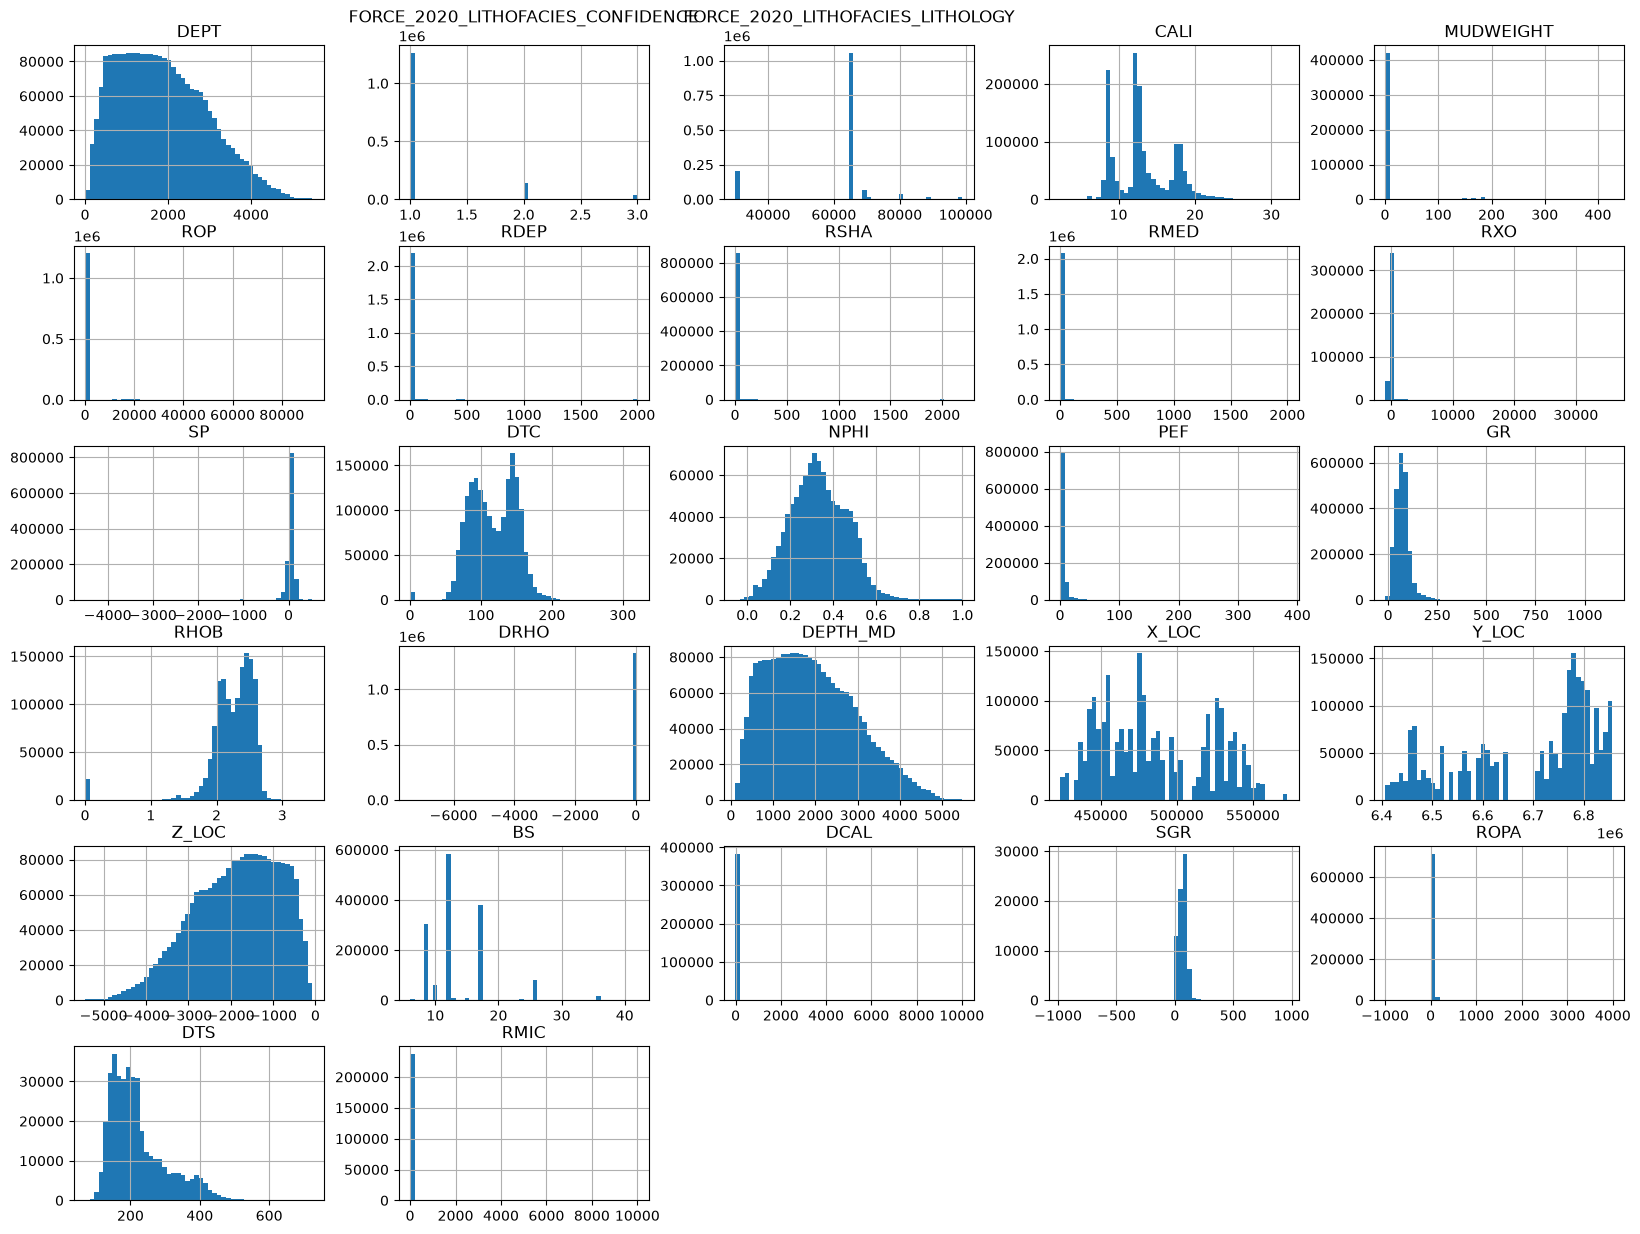

In [6]:
df_clssification.hist(bins=50, figsize=(20, 15))
plt.show()

### Spliting the data
The data is sorted by `well and depth`, **converted from lithology codes to the three target classes (Sandstone, Shale, and Limestone), and encoded as integers.** Entire wells—not individual rows—are then assigned to training or testing, which helps `prevent data leakage between the two sets.`


In [7]:
df_clssification = df_clssification.sort_values(
    ['well_name', 'DEPT']
).reset_index(drop=True)

In [8]:
mapping = {
    30000: "Sandstone",
    65000: "Shale",
    70000: "Limestone"
}

df_clssification["Lithology"] = df_clssification["FORCE_2020_LITHOFACIES_LITHOLOGY"].map(mapping)
df_clssification = df_clssification.dropna(subset=["Lithology"])
print(df_clssification["Lithology"].value_counts())

Lithology
Shale        877043
Sandstone    207704
Limestone     69498
Name: count, dtype: int64


In [9]:
le = LabelEncoder()
df_clssification["Lithology"] = le.fit_transform(df_clssification["Lithology"])

In [10]:
for i, label in enumerate(le.classes_):
    print(i, "->", label)

0 -> Limestone
1 -> Sandstone
2 -> Shale


In [11]:
wells = df_clssification["well_name"].unique()
rng = np.random.default_rng(42)
wells_shuffled = rng.permutation(wells)
n_test = int(len(wells_shuffled) * 0.2)
RandomWells = wells_shuffled[:n_test]
TrainDf_classification = df_clssification[~df_clssification["well_name"].isin(RandomWells)]
TestDf_classification = df_clssification[df_clssification["well_name"].isin(RandomWells)]

In [12]:
wells_to_remove = ['25/11-24 Jakob South', '34/12-1']
TrainDf_classification = TrainDf_classification[~TrainDf_classification["well_name"].isin(wells_to_remove)].copy()
TestDf_classification = TestDf_classification[~TestDf_classification["well_name"].isin(wells_to_remove)].copy()


In [13]:
if "Lithology" in TrainDf_classification.columns:
    print("exit")
else:
    print("not exit")

exit


In [14]:
TrainDf_classification.columns

Index(['source_file', 'well_name', 'DEPT', 'FORCE_2020_LITHOFACIES_CONFIDENCE',
       'FORCE_2020_LITHOFACIES_LITHOLOGY', 'CALI', 'MUDWEIGHT', 'ROP', 'RDEP',
       'RSHA', 'RMED', 'RXO', 'SP', 'DTC', 'NPHI', 'PEF', 'GR', 'RHOB', 'DRHO',
       'DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC', 'BS', 'DCAL', 'SGR', 'ROPA',
       'DTS', 'RMIC', 'Lithology'],
      dtype='str')

In [15]:
TrainDf_classification.shape , TestDf_classification.shape

((889755, 30), (254628, 30))

###Remove Nulls
This part measures missingness, drops selected log columns, requires a core set of available measurements.

In [16]:
percentagesNulls= TrainDf_classification.isnull().sum()/ len(TrainDf_classification)*100
print(percentagesNulls.sort_values(ascending=False))

SGR                                  97.264865
RMIC                                 85.352148
MUDWEIGHT                            79.832089
DTS                                  78.840355
DCAL                                 76.491394
ROPA                                 75.698479
RXO                                  73.710516
ROP                                  53.146878
RSHA                                 50.534810
PEF                                  41.379930
BS                                   39.853106
NPHI                                 33.222516
SP                                   33.088097
DRHO                                 16.174228
RHOB                                 13.526645
CALI                                  7.603666
DTC                                   7.409680
RMED                                  2.456856
RDEP                                  0.402358
Z_LOC                                 0.384937
DEPTH_MD                              0.384937
X_LOC        

In [17]:
cols_to_drop = [
    'SGR',
    'RMIC',
    'MUDWEIGHT',
    'DCAL',
    'RXO',
    'DTS',
    'ROPA',
    'ROP',
    'SP',
    'RSHA'
]

TrainDf_classification = TrainDf_classification.drop(columns=cols_to_drop, errors='ignore')
TestDf_classification = TestDf_classification.drop(columns=cols_to_drop, errors='ignore')


In [18]:
core_required = ['CALI', 'RDEP', 'DTC', 'RHOB', 'NPHI']
TrainDf_classification.dropna(subset=["GR"]+ core_required, inplace=True)
print('rows after requiring core log suite:', len(TrainDf_classification))

rows after requiring core log suite: 534304


In [19]:
core_required = ['CALI', 'RDEP', 'DTC', 'RHOB', 'NPHI']
TestDf_classification.dropna(subset=["GR"]+ core_required, inplace=True)
print('rows after requiring core log suite:', len(TestDf_classification))

rows after requiring core log suite: 171472


In [20]:
TrainDf_classification['DRHO'] = (
    TrainDf_classification.groupby('well_name')['DRHO']
    .transform(lambda x: x.interpolate())
)

#---
TestDf_classification['DRHO'] = (
    TestDf_classification.groupby('well_name')['DRHO']
    .transform(lambda x: x.interpolate()))

### feature engineering
New features are created from the available logs, including borehole-enlargement indicators, log ratios, relative depth, rolling mean and standard-deviation features, gradients, and frequency encodings for geological groups and formations. These transformations are applied to both training and test data.


In [ ]:
def add_washout_features(TrainDf_classification: pd.DataFrame) -> pd.DataFrame:
    TrainDf_classification = TrainDf_classification.copy()
    TrainDf_classification["CALI_BS_DIFF"] = TrainDf_classification["CALI"] - TrainDf_classification["BS"]
    TrainDf_classification["IS_WASHOUT"] = (TrainDf_classification["CALI_BS_DIFF"] > 2).astype(int)
    return TrainDf_classification


def add_ratio_features(TrainDf_classification: pd.DataFrame) -> pd.DataFrame:
    TrainDf_classification = TrainDf_classification.copy()
    eps = 1e-6

    if {"RHOB", "NPHI"}.issubset(TrainDf_classification.columns):
        TrainDf_classification["RHOB_NPHI_DIFF"] = TrainDf_classification["RHOB"] - TrainDf_classification["NPHI"]

    if {"RDEP", "RMED"}.issubset(TrainDf_classification.columns):
        TrainDf_classification["RES_RATIO"] = TrainDf_classification["RDEP"] / (TrainDf_classification["RMED"] + eps)
        TrainDf_classification["LOG_RDEP"] = np.log1p(TrainDf_classification["RDEP"].clip(lower=0))
        TrainDf_classification["LOG_RMED"] = np.log1p(TrainDf_classification["RMED"].clip(lower=0))

    if {"DTC", "RHOB"}.issubset(TrainDf_classification.columns):
        TrainDf_classification["DTC_RHOB_PROD"] = TrainDf_classification["DTC"] * TrainDf_classification["RHOB"]

    if "PEF" in TrainDf_classification.columns and "RHOB" in TrainDf_classification.columns:
        TrainDf_classification["PEF_RHOB_RATIO"] = TrainDf_classification["PEF"] / (TrainDf_classification["RHOB"] + eps)

    return TrainDf_classification


def add_rolling_features(
    TrainDf_classification: pd.DataFrame,
    cols: list,
    well_col: str = "well_name",
    depth_col: str = "DEPTH_MD",
    windows: list = (5, 15, 31),
) -> pd.DataFrame:
    TrainDf_classification = TrainDf_classification.sort_values([well_col, depth_col]).copy()
    grouped = TrainDf_classification.groupby(well_col)

    for col in cols:
        if col not in TrainDf_classification.columns:
            continue
        for w in windows:
            TrainDf_classification[f"{col}_ROLLMEAN_{w}"] = grouped[col].transform(
                lambda s: s.rolling(w, min_periods=1).mean()
            )
            TrainDf_classification[f"{col}_ROLLSTD_{w}"] = grouped[col].transform(
                lambda s: s.rolling(w, min_periods=1).std()
            )

    return TrainDf_classification


def add_gradient_features(
    TrainDf_classification: pd.DataFrame,
    cols: list,
    well_col: str = "well_name",
    depth_col: str = "DEPTH_MD",
) -> pd.DataFrame:
    TrainDf_classification = TrainDf_classification.sort_values([well_col, depth_col]).copy()
    grouped = TrainDf_classification.groupby(well_col)

    for col in cols:
        if col not in TrainDf_classification.columns:
            continue
        TrainDf_classification[f"{col}_GRAD"] = grouped[col].transform(lambda s: s.diff().fillna(0))

    return TrainDf_classification


def add_depth_features(TrainDf_classification: pd.DataFrame, well_col: str = "well_name", depth_col: str = "DEPTH_MD") -> pd.DataFrame:
    TrainDf_classification = TrainDf_classification.copy()
    well_min = TrainDf_classification.groupby(well_col)[depth_col].transform("min")
    well_max = TrainDf_classification.groupby(well_col)[depth_col].transform("max")
    span = (well_max - well_min).replace(0, np.nan)
    TrainDf_classification["DEPTH_REL"] = ((TrainDf_classification[depth_col] - well_min) / span).fillna(0)
    return TrainDf_classification


def add_group_formation_encoding(
    TrainDf_classification: pd.DataFrame,
    train_reference_df: pd.DataFrame,
    cat_cols: list = ("GROUP", "FORMATION"),
) -> pd.DataFrame:
    TrainDf_classification = TrainDf_classification.copy()
    for col in cat_cols:
        if col not in TrainDf_classification.columns:
            continue
        freq_map = train_reference_df[col].value_counts(normalize=True)
        TrainDf_classification[f"{col}_FREQ"] = TrainDf_classification[col].map(freq_map).fillna(0)
    return TrainDf_classification


def build_features(TrainDf_classification: pd.DataFrame, train_reference_df: pd.DataFrame = None) -> pd.DataFrame:
    out = TrainDf_classification.copy()
    out = add_washout_features(out)
    out = add_ratio_features(out)
    out = add_depth_features(out)
    out = add_rolling_features(out, cols=["RHOB", "NPHI", "DTC", "CALI", "PEF"])
    out = add_gradient_features(out, cols=["RHOB", "NPHI", "DTC", "CALI"])

    ref_df = train_reference_df if train_reference_df is not None else out
    out = add_group_formation_encoding(out, ref_df)

    return out

In [22]:
TrainDf_classification = build_features(TrainDf_classification, train_reference_df=TrainDf_classification)

print(TrainDf_classification.shape)
print(TrainDf_classification.columns.tolist())
TrainDf_classification.head()

(534304, 63)
['source_file', 'well_name', 'DEPT', 'FORCE_2020_LITHOFACIES_CONFIDENCE', 'FORCE_2020_LITHOFACIES_LITHOLOGY', 'CALI', 'RDEP', 'RMED', 'DTC', 'NPHI', 'PEF', 'GR', 'RHOB', 'DRHO', 'DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC', 'BS', 'Lithology', 'CALI_BS_DIFF', 'IS_WASHOUT', 'RHOB_NPHI_DIFF', 'RES_RATIO', 'LOG_RDEP', 'LOG_RMED', 'DTC_RHOB_PROD', 'PEF_RHOB_RATIO', 'DEPTH_REL', 'RHOB_ROLLMEAN_5', 'RHOB_ROLLSTD_5', 'RHOB_ROLLMEAN_15', 'RHOB_ROLLSTD_15', 'RHOB_ROLLMEAN_31', 'RHOB_ROLLSTD_31', 'NPHI_ROLLMEAN_5', 'NPHI_ROLLSTD_5', 'NPHI_ROLLMEAN_15', 'NPHI_ROLLSTD_15', 'NPHI_ROLLMEAN_31', 'NPHI_ROLLSTD_31', 'DTC_ROLLMEAN_5', 'DTC_ROLLSTD_5', 'DTC_ROLLMEAN_15', 'DTC_ROLLSTD_15', 'DTC_ROLLMEAN_31', 'DTC_ROLLSTD_31', 'CALI_ROLLMEAN_5', 'CALI_ROLLSTD_5', 'CALI_ROLLMEAN_15', 'CALI_ROLLSTD_15', 'CALI_ROLLMEAN_31', 'CALI_ROLLSTD_31', 'PEF_ROLLMEAN_5', 'PEF_ROLLSTD_5', 'PEF_ROLLMEAN_15', 'PEF_ROLLSTD_15', 'PEF_ROLLMEAN_31', 'PEF_ROLLSTD_31', 'RHOB_GRAD', 'NPHI_GRAD', 'DTC_GRAD', 'CALI_GRAD']


,source_file,well_name,DEPT,FORCE_2020_LITHOFACIES_CONFIDENCE,FORCE_2020_LITHOFACIES_LITHOLOGY,CALI,RDEP,RMED,DTC,NPHI,...,PEF_ROLLMEAN_5,PEF_ROLLSTD_5,PEF_ROLLMEAN_15,PEF_ROLLSTD_15,PEF_ROLLMEAN_31,PEF_ROLLSTD_31,RHOB_GRAD,NPHI_GRAD,DTC_GRAD,CALI_GRAD
23953,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-14,480.628001,NaN,65000.0,19.2031,1.513937,1.613886,174.347092,0.551575,...,55.815659,NaN,55.815659,NaN,55.815659,NaN,0.000000,0.000000,0.000000,0.0
23954,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-14,480.780001,NaN,65000.0,19.2031,1.480188,1.574376,176.112915,0.547566,...,48.839098,9.866347,48.839098,9.866347,48.839098,9.866347,0.000667,-0.004009,1.765823,0.0
23955,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-14,480.932001,1.0,65000.0,19.2031,1.469700,1.436627,177.662476,0.551840,...,45.422023,9.148859,45.422023,9.148859,45.422023,9.148859,-0.010537,0.004274,1.549561,0.0
23956,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-14,481.084001,1.0,65000.0,19.2031,1.469341,1.276094,177.437714,0.552511,...,44.421017,7.733636,44.421017,7.733636,44.421017,7.733636,-0.009356,0.000671,-0.224762,0.0
23957,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-14,481.236001,1.0,65000.0,19.2031,1.466462,1.204704,176.797653,0.566789,...,45.431061,7.068082,45.431061,7.068082,45.431061,7.068082,-0.008937,0.014279,-0.640060,0.0


In [ ]:
def add_washout_features(TestDf_classification: pd.DataFrame) -> pd.DataFrame:
    TestDf_classification = TestDf_classification.copy()
    TestDf_classification["CALI_BS_DIFF"] = TestDf_classification["CALI"] - TestDf_classification["BS"]
    TestDf_classification["IS_WASHOUT"] = (TestDf_classification["CALI_BS_DIFF"] > 2).astype(int)
    return TestDf_classification


def add_ratio_features(TestDf_classification: pd.DataFrame) -> pd.DataFrame:
    TestDf_classification = TestDf_classification.copy()
    eps = 1e-6

    if {"RHOB", "NPHI"}.issubset(TestDf_classification.columns):
        TestDf_classification["RHOB_NPHI_DIFF"] = TestDf_classification["RHOB"] - TestDf_classification["NPHI"]

    if {"RDEP", "RMED"}.issubset(TestDf_classification.columns):
        TestDf_classification["RES_RATIO"] = TestDf_classification["RDEP"] / (TestDf_classification["RMED"] + eps)
        TestDf_classification["LOG_RDEP"] = np.log1p(TestDf_classification["RDEP"].clip(lower=0))
        TestDf_classification["LOG_RMED"] = np.log1p(TestDf_classification["RMED"].clip(lower=0))

    if {"DTC", "RHOB"}.issubset(TestDf_classification.columns):
        TestDf_classification["DTC_RHOB_PROD"] = TestDf_classification["DTC"] * TestDf_classification["RHOB"]

    if "PEF" in TestDf_classification.columns and "RHOB" in TestDf_classification.columns:
        TestDf_classification["PEF_RHOB_RATIO"] = TestDf_classification["PEF"] / (TestDf_classification["RHOB"] + eps)

    return TestDf_classification


def add_rolling_features(
    TestDf_classification: pd.DataFrame,
    cols: list,
    well_col: str = "well_name",
    depth_col: str = "DEPTH_MD",
    windows: list = (5, 15, 31),
) -> pd.DataFrame:
    TestDf_classification = TestDf_classification.sort_values([well_col, depth_col]).copy()
    grouped = TestDf_classification.groupby(well_col)

    for col in cols:
        if col not in TestDf_classification.columns:
            continue
        for w in windows:
            TestDf_classification[f"{col}_ROLLMEAN_{w}"] = grouped[col].transform(
                lambda s: s.rolling(w, min_periods=1).mean()
            )
            TestDf_classification[f"{col}_ROLLSTD_{w}"] = grouped[col].transform(
                lambda s: s.rolling(w, min_periods=1).std()
            )

    return TestDf_classification


def add_gradient_features(
    TestDf_classification: pd.DataFrame,
    cols: list,
    well_col: str = "well_name",
    depth_col: str = "DEPTH_MD",
) -> pd.DataFrame:
    TestDf_classification = TestDf_classification.sort_values([well_col, depth_col]).copy()
    grouped = TestDf_classification.groupby(well_col)

    for col in cols:
        if col not in TestDf_classification.columns:
            continue
        TestDf_classification[f"{col}_GRAD"] = grouped[col].transform(lambda s: s.diff().fillna(0))

    return TestDf_classification


def add_depth_features(TestDf_classification: pd.DataFrame, well_col: str = "well_name", depth_col: str = "DEPTH_MD") -> pd.DataFrame:
    TestDf_classification = TestDf_classification.copy()
    well_min = TestDf_classification.groupby(well_col)[depth_col].transform("min")
    well_max = TestDf_classification.groupby(well_col)[depth_col].transform("max")
    span = (well_max - well_min).replace(0, np.nan)
    TestDf_classification["DEPTH_REL"] = ((TestDf_classification[depth_col] - well_min) / span).fillna(0)
    return TestDf_classification


def add_group_formation_encoding(
    TestDf_classification: pd.DataFrame,
    train_reference_df: pd.DataFrame,
    cat_cols: list = ("GROUP", "FORMATION"),
) -> pd.DataFrame:
    TestDf_classification = TestDf_classification.copy()
    for col in cat_cols:
        if col not in TestDf_classification.columns:
            continue
        freq_map = train_reference_df[col].value_counts(normalize=True)
        TestDf_classification[f"{col}_FREQ"] = TestDf_classification[col].map(freq_map).fillna(0)
    return TestDf_classification


def build_features(TestDf_classification: pd.DataFrame, train_reference_df: pd.DataFrame = None) -> pd.DataFrame:
    out = TestDf_classification.copy()
    out = add_washout_features(out)
    out = add_ratio_features(out)
    out = add_depth_features(out)
    out = add_rolling_features(out, cols=["RHOB", "NPHI", "DTC", "CALI", "PEF"])
    out = add_gradient_features(out, cols=["RHOB", "NPHI", "DTC", "CALI"])

    ref_df = train_reference_df if train_reference_df is not None else out
    out = add_group_formation_encoding(out, ref_df)

    return out

In [24]:
TestDf_classification = build_features(TestDf_classification, train_reference_df=TestDf_classification)

print(TestDf_classification.shape)
print(TestDf_classification.columns.tolist())
TestDf_classification.head()

(171472, 63)
['source_file', 'well_name', 'DEPT', 'FORCE_2020_LITHOFACIES_CONFIDENCE', 'FORCE_2020_LITHOFACIES_LITHOLOGY', 'CALI', 'RDEP', 'RMED', 'DTC', 'NPHI', 'PEF', 'GR', 'RHOB', 'DRHO', 'DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC', 'BS', 'Lithology', 'CALI_BS_DIFF', 'IS_WASHOUT', 'RHOB_NPHI_DIFF', 'RES_RATIO', 'LOG_RDEP', 'LOG_RMED', 'DTC_RHOB_PROD', 'PEF_RHOB_RATIO', 'DEPTH_REL', 'RHOB_ROLLMEAN_5', 'RHOB_ROLLSTD_5', 'RHOB_ROLLMEAN_15', 'RHOB_ROLLSTD_15', 'RHOB_ROLLMEAN_31', 'RHOB_ROLLSTD_31', 'NPHI_ROLLMEAN_5', 'NPHI_ROLLSTD_5', 'NPHI_ROLLMEAN_15', 'NPHI_ROLLSTD_15', 'NPHI_ROLLMEAN_31', 'NPHI_ROLLSTD_31', 'DTC_ROLLMEAN_5', 'DTC_ROLLSTD_5', 'DTC_ROLLMEAN_15', 'DTC_ROLLSTD_15', 'DTC_ROLLMEAN_31', 'DTC_ROLLSTD_31', 'CALI_ROLLMEAN_5', 'CALI_ROLLSTD_5', 'CALI_ROLLMEAN_15', 'CALI_ROLLSTD_15', 'CALI_ROLLMEAN_31', 'CALI_ROLLSTD_31', 'PEF_ROLLMEAN_5', 'PEF_ROLLSTD_5', 'PEF_ROLLMEAN_15', 'PEF_ROLLSTD_15', 'PEF_ROLLMEAN_31', 'PEF_ROLLSTD_31', 'RHOB_GRAD', 'NPHI_GRAD', 'DTC_GRAD', 'CALI_GRAD']


,source_file,well_name,DEPT,FORCE_2020_LITHOFACIES_CONFIDENCE,FORCE_2020_LITHOFACIES_LITHOLOGY,CALI,RDEP,RMED,DTC,NPHI,...,PEF_ROLLMEAN_5,PEF_ROLLSTD_5,PEF_ROLLMEAN_15,PEF_ROLLSTD_15,PEF_ROLLMEAN_31,PEF_ROLLSTD_31,RHOB_GRAD,NPHI_GRAD,DTC_GRAD,CALI_GRAD
7327,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-13 Sleipner East Appr,1138.704,1.0,30000.0,19.322735,1.091499,1.013309,147.837677,0.765867,...,1.631495,NaN,1.631495,NaN,1.631495,NaN,0.000000,0.000000,0.000000,0.000000
7328,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-13 Sleipner East Appr,1138.856,1.0,65000.0,18.613674,1.122706,1.088184,142.382431,0.800262,...,1.638288,0.009606,1.638288,0.009606,1.638288,0.009606,0.026360,0.034395,-5.455246,-0.709061
7329,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-13 Sleipner East Appr,1139.008,1.0,65000.0,18.212072,1.148141,1.127155,138.258331,0.765957,...,1.640816,0.008082,1.640816,0.008082,1.640816,0.008082,0.016710,-0.034305,-4.124100,-0.401602
7330,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-13 Sleipner East Appr,1139.160,1.0,65000.0,18.134182,1.170984,1.141467,139.198914,0.702521,...,1.635666,0.012232,1.635666,0.012232,1.635666,0.012232,0.011637,-0.063436,0.940582,-0.077890
7331,Force_2020_all_wells_train_test_blind_hidden_f...,15/9-13 Sleipner East Appr,1139.312,1.0,65000.0,18.033762,1.184080,1.138007,144.290085,0.639708,...,1.609504,0.059453,1.609504,0.059453,1.609504,0.059453,-0.015480,-0.062813,5.091171,-0.100420


## Building the model
Features are separated from the lithology target and an XGBoost classifier is configured. Its performance is first estimated with grouped cross-validation, which keeps samples from any one well together, before the final model is trained on all training data.


### Model training

In [25]:
X_classification= TrainDf_classification.drop(columns=["Lithology", "well_name", "source_file" , "FORCE_2020_LITHOFACIES_LITHOLOGY"], errors='ignore')
Y_classification = TrainDf_classification["Lithology"]
groups_classification= TrainDf_classification["well_name"]

In [26]:
ClassificationModel= XGBClassifier(n_estimators=500, max_depth=8, learning_rate=0.05, n_jobs=-1, random_state=42)
ClassificationModel.fit(X_classification, Y_classification)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [27]:
scores= cross_val_score(
    ClassificationModel,
    X_classification,
    Y_classification,
    groups= groups_classification,
    cv=GroupKFold(n_splits=4),
    scoring= "f1_macro"
)

In [28]:
scores

array([0.80015941, 0.83595155, 0.83053198, 0.85859677])

### Saving the model

In [ ]:
joblib.dump(ClassificationModel, "XGBoost_Lithology_Classification_Model.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

### Test on testing data
The fitted classifier is saved together with the label encoder, then used to predict the held-out wells. The following cells report precision, recall, F1 scores, and a confusion matrix to assess classification performance.


In [30]:
Xtest_classification= TestDf_classification.drop(columns=["Lithology", "well_name", "source_file" , "FORCE_2020_LITHOFACIES_LITHOLOGY"], errors='ignore')
Ytest_classification= TestDf_classification["Lithology"]

In [37]:
y_pred = ClassificationModel.predict(Xtest_classification)
condusionmatrix=confusion_matrix(Ytest_classification, y_pred)

In [38]:
Report= classification_report(Ytest_classification, y_pred)
print(Report)

              precision    recall  f1-score   support

           0       0.84      0.74      0.79     11734
           1       0.84      0.84      0.84     25521
           2       0.96      0.97      0.96    134217

    accuracy                           0.93    171472
   macro avg       0.88      0.85      0.86    171472
weighted avg       0.93      0.93      0.93    171472



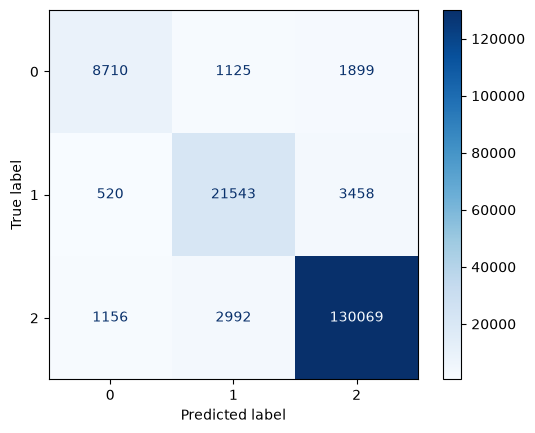

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(Ytest_classification, y_pred, cmap="Blues")
plt.show()

### Feature importance
This final step ranks the engineered input features by their importance in the trained XGBoost model. The ranking helps identify which measurements influenced predictions most, but it should not be interpreted as proof of causation.


In [34]:
importance= pd.DataFrame({

"feature": Xtest_classification.columns,
"importance": ClassificationModel.feature_importances_
})
importance = importance.sort_values(
    by="importance",
    ascending=False
)

print(importance)

                              feature  importance
6                                NPHI    0.133533
8                                  GR    0.113854
9                                RHOB    0.059731
31                    NPHI_ROLLMEAN_5    0.056552
15                                 BS    0.048283
21                           LOG_RMED    0.041908
43                    CALI_ROLLMEAN_5    0.041285
14                              Z_LOC    0.036591
22                      DTC_RHOB_PROD    0.033494
0                                DEPT    0.032179
25                    RHOB_ROLLMEAN_5    0.029646
12                              X_LOC    0.023226
4                                RMED    0.018744
38                      DTC_ROLLSTD_5    0.018129
13                              Y_LOC    0.018031
17                         IS_WASHOUT    0.014579
16                       CALI_BS_DIFF    0.014253
45                   CALI_ROLLMEAN_15    0.013858
33                   NPHI_ROLLMEAN_15    0.013839


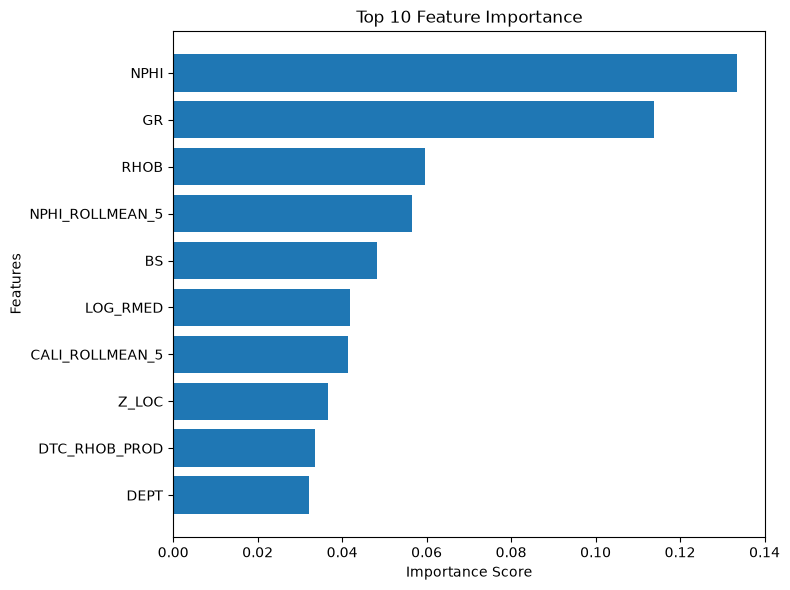

In [35]:
import matplotlib.pyplot as plt

top10 = importance.sort_values(
    by="importance",
    ascending=False
).head(10)

plt.figure(figsize=(8, 6))
plt.barh(top10["feature"][::-1], top10["importance"][::-1])

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()